# Q1 Part 2 — Jacobi / GS / SOR comparison, velocity plots, grid & domain checks
Addresses spec A.1 and A.2.

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from utils_final import (solve_potential, Usurf_on_y0, compute_uv,
                         dYb_dx, omega_opt_theory)

def hist_arrays(info):
    h = info["hist"]
    return (np.array([r["it"]  for r in h]),
            np.array([r["res"] for r in h]),
            np.array([r["upd"] for r in h]),
            np.array([r["time"] for r in h]),
            np.array([r.get("rho_est", np.nan) for r in h]))

In [112]:
# ─── Baseline parameters ───
eps, M = 0.01, 0.1
q, s, r = 4.0, 4.0, 4.0
Nx, Ny = 161, 81

TOL_RES = 1e-5
TOL_UPD = 1e-5
MAX_ITER = 50000   # Jacobi needs ~40k on this grid
CHECK = 200

omega0 = 1.7  # reasonable starting guess for SOR

# ─── Run all three methods ───
runs = {}
for meth in ("jacobi", "gs", "sor"):
    w = omega0 if meth == "sor" else 1.0
    phi, x, y, info = solve_potential(
        eps=eps, M=M, q=q, s=s, r=r, Nx=Nx, Ny=Ny,
        method=meth, omega=w,
        tol_res=TOL_RES, tol_upd=TOL_UPD,
        max_iter=MAX_ITER, check_every=CHECK,
        verbose=False,
    )
    label = meth if meth != "sor" else f"sor(ω={omega0})"
    runs[label] = (phi, x, y, info)
    print(f"{label:14s}  converged={info['converged']}  iters={info['iters']:6d}  time={info['seconds']:.2f}s")

jacobi          converged=True  iters= 37000  time=1.28s
gs              converged=True  iters= 22600  time=3.66s
sor(ω=1.7)      converged=True  iters=  5600  time=0.99s


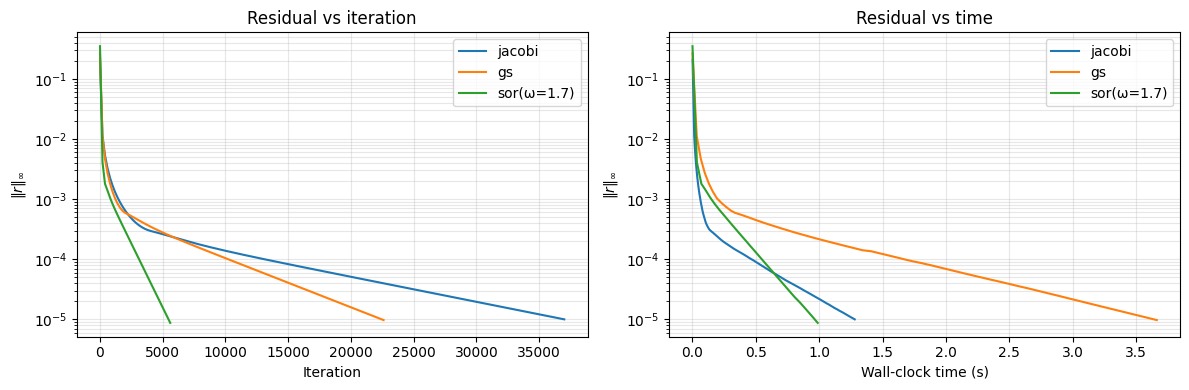

In [113]:
# ─── Convergence history: residual vs iteration ───
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for tag, (_, _, _, info) in runs.items():
    it, res, upd, t, rho = hist_arrays(info)
    axes[0].semilogy(it, res, label=tag)
    axes[1].semilogy(t, res, label=tag)

axes[0].set_xlabel("Iteration"); axes[0].set_ylabel(r"$\|r\|_\infty$")
axes[0].set_title("Residual vs iteration"); axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)
axes[1].set_xlabel("Wall-clock time (s)"); axes[1].set_ylabel(r"$\|r\|_\infty$")
axes[1].set_title("Residual vs time"); axes[1].legend(); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

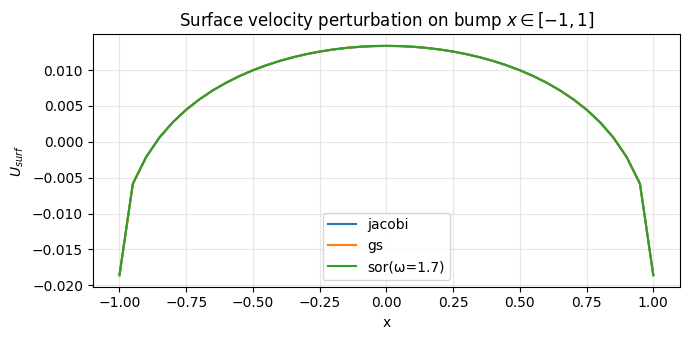

In [114]:
# ─── U_surf on the bump x ∈ [-1,1] — all three methods ───
fig, ax = plt.subplots(figsize=(7, 3.5))
for tag, (phi, x, y, info) in runs.items():
    mask = (x >= -1.0) & (x <= 1.0)
    u0 = Usurf_on_y0(phi, info["dx"])
    ax.plot(x[mask], u0[mask], label=tag)
ax.set_xlabel("x"); ax.set_ylabel(r"$U_{surf}$")
ax.set_title(r"Surface velocity perturbation on bump $x\in[-1,1]$")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

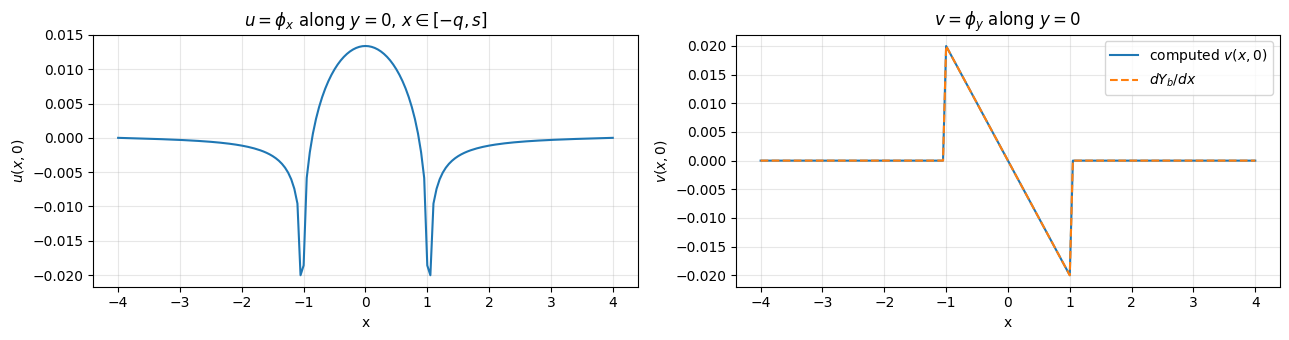

In [115]:
# ─── Take SOR solution for remaining plots ───
phi_ref, x, y, info_ref = runs[f"sor(ω={omega0})"]
dx, dy = info_ref["dx"], info_ref["dy"]
u, v = compute_uv(phi_ref, dx, dy)

# u along full wall y = 0
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(x, u[:, 0])
axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$u(x,0)$")
axes[0].set_title(r"$u=\phi_x$ along $y=0$, $x\in[-q,s]$"); axes[0].grid(True, alpha=0.3)

# v along wall y = 0 (should match BC)
g_exact = dYb_dx(x, eps)
axes[1].plot(x, v[:, 0], label=r"computed $v(x,0)$")
axes[1].plot(x, g_exact, "--", label=r"$dY_b/dx$")
axes[1].set_xlabel("x"); axes[1].set_ylabel(r"$v(x,0)$")
axes[1].set_title(r"$v=\phi_y$ along $y=0$"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

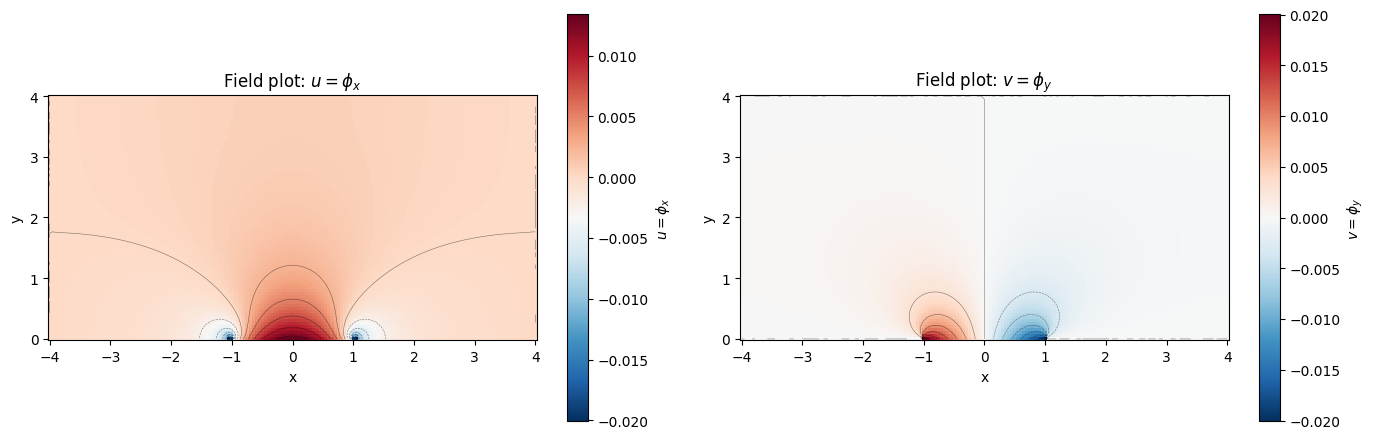

In [116]:
# ─── Field colour plots of (u, v) with contour overlay ───
X, Y = np.meshgrid(x, y, indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, field, label in zip(axes, [u, v], [r"$u = \phi_x$", r"$v = \phi_y$"]):
    pcm = ax.pcolormesh(X, Y, field, shading="auto", cmap="RdBu_r")
    ax.contour(X, Y, field, levels=15, colors="k", linewidths=0.4, alpha=0.5)
    fig.colorbar(pcm, ax=ax, label=label)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"Field plot: {label}")
    ax.set_aspect("equal")

plt.tight_layout(); plt.show()

In [117]:
# ═══════════════════════════════════════════════════
# Grid-independence and domain-placement tests  (A.2)
# ═══════════════════════════════════════════════════
def get_usurf_profile(eps, M, q, s, r, Nx, Ny, omega=1.7):
    """Return (x_bump, Usurf_bump, info) for a converged SOR run."""
    phi, x, y, info = solve_potential(
        eps=eps, M=M, q=q, s=s, r=r, Nx=Nx, Ny=Ny,
        method="sor", omega=omega,
        tol_res=TOL_RES, tol_upd=TOL_UPD,
        max_iter=MAX_ITER, check_every=CHECK, verbose=False,
    )
    u, _ = compute_uv(phi, info["dx"], info["dy"])
    mask = (x >= -1.0) & (x <= 1.0)
    return x[mask], u[mask, 0], info

def max_diff(sigA, sigB):
    xA, uA, _ = sigA
    xB, uB, _ = sigB
    return float(np.max(np.abs(uA - np.interp(xA, xB, uB))))

domain=3: Nx=241 Ny=121  conv=True  iters=13800
domain=4: Nx=321 Ny=161  conv=True  iters=20800
domain=6: Nx=481 Ny=241  conv=True  iters=35800
  max|ΔUsurf| (3→4): 1.86e-04
  max|ΔUsurf| (4→6): 1.35e-04


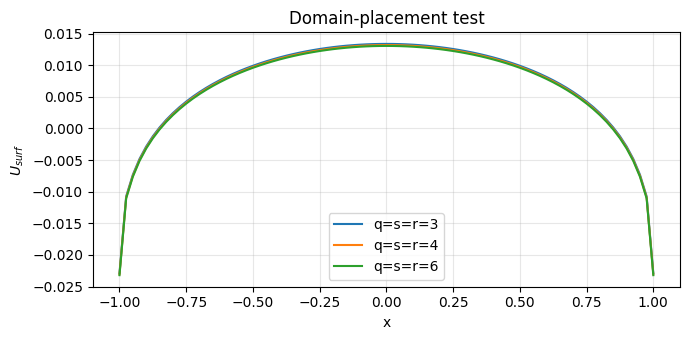

In [118]:
# (a) Domain growth: (q,s,r) = 3 → 4 → 6, fixed Nx×Ny per unit (≈40 pts/unit)
sigs_dom = {}
for D in [3, 4, 6]:
    Nx_d = int(40 * 2 * D) + 1      # ≈ 40 pts per unit in x
    Ny_d = int(40 * D) + 1
    sig = get_usurf_profile(eps, M, q=D, s=D, r=D, Nx=Nx_d, Ny=Ny_d)
    sigs_dom[D] = sig
    print(f"domain={D}: Nx={Nx_d} Ny={Ny_d}  conv={sig[2]['converged']}  iters={sig[2]['iters']}")

for Da, Db in [(3,4), (4,6)]:
    print(f"  max|ΔUsurf| ({Da}→{Db}): {max_diff(sigs_dom[Da], sigs_dom[Db]):.2e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
for D, sig in sigs_dom.items():
    ax.plot(sig[0], sig[1], label=f"q=s=r={D}")
ax.set_xlabel("x"); ax.set_ylabel(r"$U_{surf}$")
ax.set_title("Domain-placement test"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

  81×41  conv=True  iters=1800
  161×81  conv=True  iters=5600
  241×121  conv=True  iters=12000
  321×161  conv=True  iters=20800
  max|ΔUsurf| (81, 41)→(161, 81): 4.54e-03
  max|ΔUsurf| (161, 81)→(241, 121): 2.63e-03
  max|ΔUsurf| (241, 121)→(321, 161): 1.86e-03


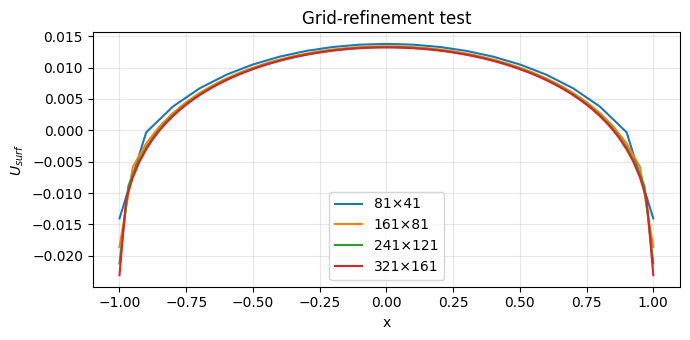

In [120]:
# (b) Grid refinement: fixed domain q=s=r=4, increasing Nx×Ny
sigs_grid = {}
for Nx_g, Ny_g in [(81, 41), (161, 81), (241, 121), (321, 161)]:
    sig = get_usurf_profile(eps, M, q=4, s=4, r=4, Nx=Nx_g, Ny=Ny_g)
    sigs_grid[(Nx_g, Ny_g)] = sig
    print(f"  {Nx_g}×{Ny_g}  conv={sig[2]['converged']}  iters={sig[2]['iters']}")

keys = list(sigs_grid.keys())
for i in range(len(keys) - 1):
    d = max_diff(sigs_grid[keys[i]], sigs_grid[keys[i+1]])
    print(f"  max|ΔUsurf| {keys[i]}→{keys[i+1]}: {d:.2e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
for k, sig in sigs_grid.items():
    ax.plot(sig[0], sig[1], label=f"{k[0]}×{k[1]}")
ax.set_xlabel("x"); ax.set_ylabel(r"$U_{surf}$")
ax.set_title("Grid-refinement test"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()